In [1]:
from sklearn import datasets #iris datasetini kullanmak için sklearn kullanıldı
import pandas as pd
import numpy as np
iris = datasets.load_iris()  #iris dataseti iris nesnesi atandı. iris nesnesi "dict-sözlük" türündedir.
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [2]:
#iris nesnesi sözlük türünden pandas DataFrame'ine çevirmek için aşağıdaki komut kullanıldı
iris = pd.DataFrame(data = np.c_[iris['data'], iris['target']],
                   columns = iris['feature_names'] + ['target'])

In [4]:
#iris nesnesi artık pandas DataFrame'i haline gelmiştir
iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [6]:
# iris DataFrame'ine species diye bir alan ekleyip, target değeri 0 ise setosa, 1 ise versicolor, 2 ise virginica değeri 
# atamak için aşağıdaki kod kullanıldı
species = []
for i in range(len(iris['target'])):
    if iris['target'][i] == 0:
        species.append("setosa")
    elif iris['target'][i] == 1:
        species.append("versicolor")
    else: 
        species.append("virginica")

iris['species'] = species 
    

In [7]:
iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0.0,setosa
1,4.9,3.0,1.4,0.2,0.0,setosa
2,4.7,3.2,1.3,0.2,0.0,setosa
3,4.6,3.1,1.5,0.2,0.0,setosa
4,5.0,3.6,1.4,0.2,0.0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0,virginica
146,6.3,2.5,5.0,1.9,2.0,virginica
147,6.5,3.0,5.2,2.0,2.0,virginica
148,6.2,3.4,5.4,2.3,2.0,virginica


In [8]:
iris.groupby('species').size()

species
setosa        50
versicolor    50
virginica     50
dtype: int64

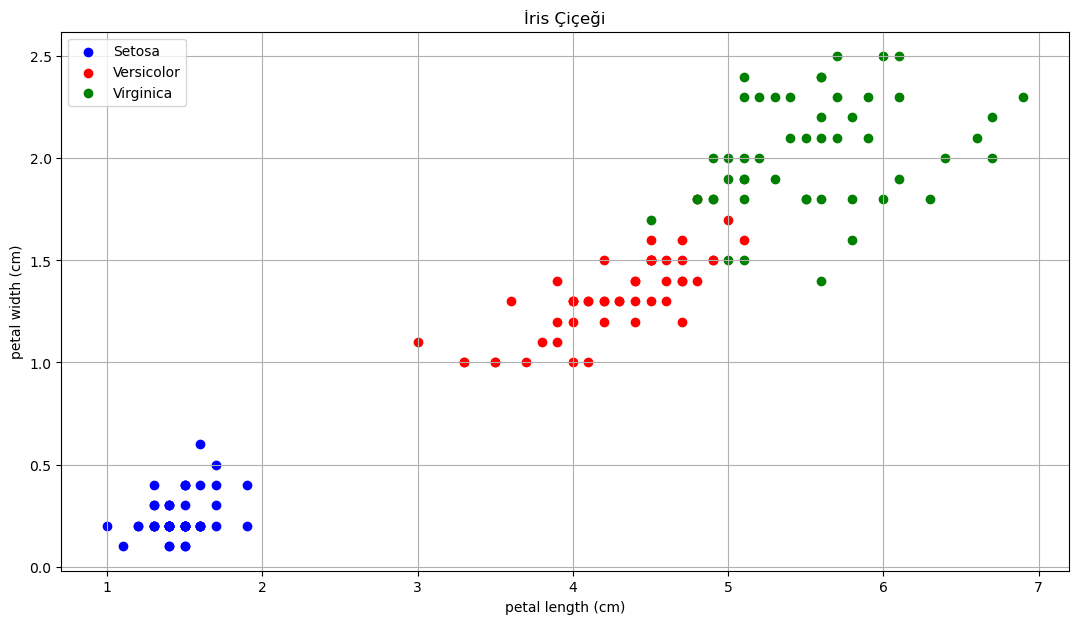

In [11]:
#verisetinin grafiğini oluşturma - PETAL Yaprağına göre grafiği oluştur
import matplotlib.pyplot as plt
setosa = iris[iris.species == "setosa"]
versicolor = iris[iris.species == "versicolor"]
virginica = iris[iris.species == "virginica"]

fig, ax = plt.subplots()
fig.set_size_inches(13,7)

ax.scatter(setosa['petal length (cm)'], setosa['petal width (cm)'], label = "Setosa", facecolor="blue")
ax.scatter(versicolor['petal length (cm)'], versicolor['petal width (cm)'], label = "Versicolor", facecolor="red")
ax.scatter(virginica['petal length (cm)'], virginica['petal width (cm)'], label = "Virginica", facecolor="green")

ax.set_xlabel('petal length (cm)')
ax.set_ylabel('petal width (cm)')
ax.grid()
ax.set_title("İris Çiçeği")
ax.legend()

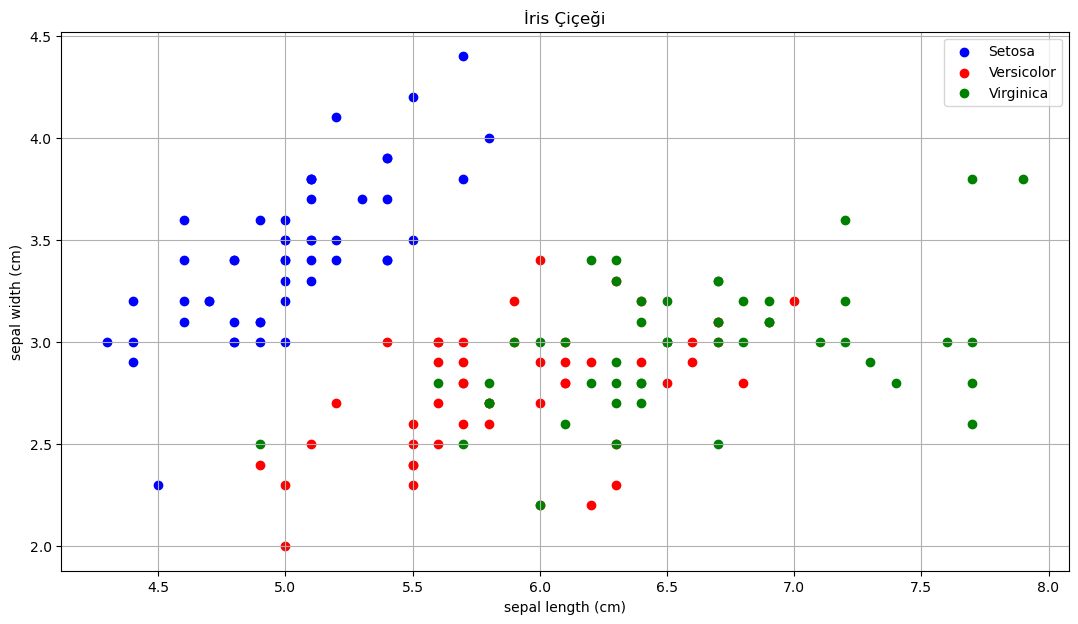

In [12]:
#verisetinin grafiğini oluşturma - SEPAL Yaprağına göre grafiği oluştur
import matplotlib.pyplot as plt
setosa = iris[iris.species == "setosa"]
versicolor = iris[iris.species == "versicolor"]
virginica = iris[iris.species == "virginica"]

fig, ax = plt.subplots()
fig.set_size_inches(13,7)

ax.scatter(setosa['sepal length (cm)'], setosa['sepal width (cm)'], label = "Setosa", facecolor="blue")
ax.scatter(versicolor['sepal length (cm)'], versicolor['sepal width (cm)'], label = "Versicolor", facecolor="red")
ax.scatter(virginica['sepal length (cm)'], virginica['sepal width (cm)'], label = "Virginica", facecolor="green")

ax.set_xlabel('sepal length (cm)')
ax.set_ylabel('sepal width (cm)')
ax.grid()
ax.set_title("İris Çiçeği")
ax.legend()

In [25]:
from sklearn.model_selection import train_test_split

#Dataset içinden özellikleri alıp X dizisine attık
X = iris.drop(['target','species'], axis=1)
#yukarıdaki grafikler incelendiğinde özellikler içinde pedal değerleri gruplandırma için daha anlamlı olduğu
#için pedal değerleri alındı
X = X.to_numpy()[:,(2,3)]

#datase
y = iris['target']
y = y.to_numpy()

print(X)
print(y)

[[1.4 0.2]
 [1.4 0.2]
 [1.3 0.2]
 [1.5 0.2]
 [1.4 0.2]
 [1.7 0.4]
 [1.4 0.3]
 [1.5 0.2]
 [1.4 0.2]
 [1.5 0.1]
 [1.5 0.2]
 [1.6 0.2]
 [1.4 0.1]
 [1.1 0.1]
 [1.2 0.2]
 [1.5 0.4]
 [1.3 0.4]
 [1.4 0.3]
 [1.7 0.3]
 [1.5 0.3]
 [1.7 0.2]
 [1.5 0.4]
 [1.  0.2]
 [1.7 0.5]
 [1.9 0.2]
 [1.6 0.2]
 [1.6 0.4]
 [1.5 0.2]
 [1.4 0.2]
 [1.6 0.2]
 [1.6 0.2]
 [1.5 0.4]
 [1.5 0.1]
 [1.4 0.2]
 [1.5 0.2]
 [1.2 0.2]
 [1.3 0.2]
 [1.4 0.1]
 [1.3 0.2]
 [1.5 0.2]
 [1.3 0.3]
 [1.3 0.3]
 [1.3 0.2]
 [1.6 0.6]
 [1.9 0.4]
 [1.4 0.3]
 [1.6 0.2]
 [1.4 0.2]
 [1.5 0.2]
 [1.4 0.2]
 [4.7 1.4]
 [4.5 1.5]
 [4.9 1.5]
 [4.  1.3]
 [4.6 1.5]
 [4.5 1.3]
 [4.7 1.6]
 [3.3 1. ]
 [4.6 1.3]
 [3.9 1.4]
 [3.5 1. ]
 [4.2 1.5]
 [4.  1. ]
 [4.7 1.4]
 [3.6 1.3]
 [4.4 1.4]
 [4.5 1.5]
 [4.1 1. ]
 [4.5 1.5]
 [3.9 1.1]
 [4.8 1.8]
 [4.  1.3]
 [4.9 1.5]
 [4.7 1.2]
 [4.3 1.3]
 [4.4 1.4]
 [4.8 1.4]
 [5.  1.7]
 [4.5 1.5]
 [3.5 1. ]
 [3.8 1.1]
 [3.7 1. ]
 [3.9 1.2]
 [5.1 1.6]
 [4.5 1.5]
 [4.5 1.6]
 [4.7 1.5]
 [4.4 1.3]
 [4.1 1.3]
 [4.  1.3]
 [4.4 1.2]

In [28]:
#dataseti %80 eğitim %20 test olarak ayırdık
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [30]:
#Logistic Regresyon Modeli Ayarlandı
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(random_state=16)

#Eğitim başlatıldı
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=16)

In [35]:
# Eğitim özelliklerine göre tahminler
train_pred = log_reg.predict(X_train)
train_pred

array([0., 0., 1., 0., 0., 2., 1., 0., 0., 0., 2., 1., 1., 0., 0., 1., 2.,
       2., 1., 2., 1., 2., 1., 0., 2., 1., 0., 0., 0., 1., 2., 0., 0., 0.,
       1., 0., 1., 2., 0., 1., 2., 0., 2., 2., 1., 1., 2., 1., 0., 1., 2.,
       0., 0., 1., 2., 0., 2., 0., 0., 2., 1., 2., 2., 2., 2., 1., 0., 0.,
       1., 2., 0., 0., 0., 1., 2., 0., 2., 2., 0., 1., 1., 2., 1., 2., 0.,
       2., 1., 2., 1., 1., 1., 0., 1., 1., 0., 1., 2., 2., 0., 1., 2., 2.,
       0., 2., 0., 1., 2., 2., 1., 2., 1., 1., 2., 2., 0., 1., 1., 0., 1.,
       2.])

In [36]:
# Test özelliklerine göre tahminler
test_pred = log_reg.predict(X_test)
test_pred

array([1., 0., 2., 1., 1., 0., 1., 2., 1., 1., 2., 0., 0., 0., 0., 1., 2.,
       1., 1., 2., 0., 2., 0., 2., 2., 2., 2., 2., 0., 0.])

In [37]:
# Modelin başarı durumu gösterme
from sklearn import metrics

print("Başarı Durumu\n")

print(metrics.classification_report(y_train, train_pred, digits=3))

Başarı Durumu

              precision    recall  f1-score   support

         0.0      1.000     1.000     1.000        40
         1.0      0.950     0.927     0.938        41
         2.0      0.925     0.949     0.937        39

    accuracy                          0.958       120
   macro avg      0.958     0.959     0.958       120
weighted avg      0.959     0.958     0.958       120



In [38]:
# modelin kamraşıklık matrisi 
print(metrics.confusion_matrix(y_train, train_pred))

[[40  0  0]
 [ 0 38  3]
 [ 0  2 37]]
